In [66]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


transform = transforms.Compose([
    transforms.ToTensor(),  # converts image to tensor (0-255 → 0-1)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # normalize
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)

print("Training images:", len(trainset))
print("Test images:", len(testset))
print("Image shape:", trainset[0][0].shape)

Training images: 50000
Test images: 10000
Image shape: torch.Size([3, 32, 32])


In [67]:
from torch.utils.data import DataLoader


trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

print("Total batches in training:", len(trainloader))
print("Total batches in testing:", len(testloader))

Total batches in training: 1563
Total batches in testing: 313


In [68]:
import torchvision.models as models

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model = model.to(device)


print(model.fc)

Linear(in_features=2048, out_features=1000, bias=True)


In [69]:
import torch.nn as nn
model.fc = nn.Linear(2048, 10)
model = model.to(device)
print(model.fc)

Linear(in_features=2048, out_features=10, bias=True)


In [70]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [71]:
epochs = 10  

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in trainloader:  # loop through batches
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(trainloader):.4f}")

Epoch [1/10], Loss: 0.9797
Epoch [2/10], Loss: 0.6498
Epoch [3/10], Loss: 0.5380
Epoch [4/10], Loss: 0.4711
Epoch [5/10], Loss: 0.3882
Epoch [6/10], Loss: 0.3402
Epoch [7/10], Loss: 0.2738
Epoch [8/10], Loss: 0.2637
Epoch [9/10], Loss: 0.1965
Epoch [10/10], Loss: 0.1839


In [72]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 84.22%


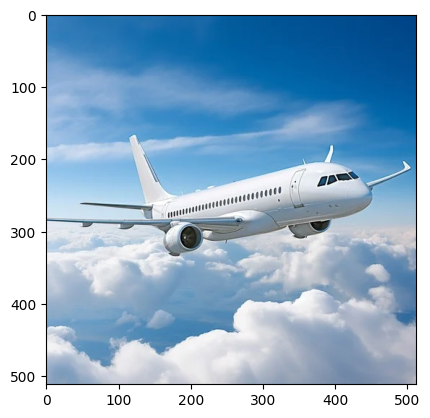

Model predicted: airplane


In [73]:
from PIL import Image
import torchvision.transforms as transforms


transform_test = transforms.Compose([
    transforms.Resize((32, 32)),     
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

#Cat_November_2010-1a.jpg
#airplane-mid-flight-stockcake.jpg
img_path = "airplane-mid-flight-stockcake.jpg"  # put your image path here
img = Image.open(img_path)


plt.imshow(img)
plt.show()

img_tensor = transform_test(img).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    print(f"Model predicted: {classes[predicted[0]]}")

In [75]:
torch.save(model.state_dict(), 'cifar10_resnet50new.pth')
print("Model saved!")

Model saved!
